In [1]:
import json
from datetime import datetime
import os
import numpy as np
import numpy as np
from math import log2

np.random.seed(42)
# np.random.seed(3)
"""Configuration"""
config = {
    "n": 10,
    "K": 5,
    "eta_2": 0.1,
    "cost_type": "deviation",
    "cost_coe": None,
    "data_source": "uni-TvN9-pure",  # uni-TvN9-pure, uni-TvN9-reverse-pure; ml-100k, amz, music
    "user_normal": False,
    "experiment_type": "B-V tradeoff",
    "attention": "log",
    "tau": 0.05,
    "dataset_dir": "datasets/NMF",
    "mechanisms": ["BRCM_star", "M3_expo", "M3_enga", "M3_0"]
}


In [2]:
# Global Variants
n = config["n"]  # creator count
K = config["K"]  # Top-K recommendation
eta_2 = config["eta_2"]  # lr of each step in LBR algo
cost_coe = config["cost_coe"]  # cost coefficient
user_normal = config["user_normal"]
expe_type = config["experiment_type"]
mechanisms = config["mechanisms"]
data_source = config["data_source"]

# synthetic
if data_source.startswith('uni'): 
    lambdas = np.array([0, 0.01, 0.1, 1, 10, 100, 1e3])
    sigma_noises = [0.5] * 10
# benchmark datasets
elif data_source in ['ml-100k', 'ml-1m']:
    lambdas = np.round(np.linspace(0, 2, 11), 2)
    sigma_noises = [0.3] * 10
elif data_source in ['amz', 'music']:
    lambdas = np.round(np.linspace(0, 1, 11), 2)
    sigma_noises = [0.3] * 10
else:
    raise NotImplementedError("Invalid data source")

if expe_type == "Mechanisms":
    total_trial = 10
    groups = mechanisms
if expe_type == "B-V tradeoff":
    groups = lambdas
    total_trial = len(sigma_noises)

lambdas_static = lambdas
total_group = len(groups)
total_group_static = len(lambdas_static)

# other parameter configurations
time_steps = 100 * n + 500
if data_source in ['ml-100k']:
    m, d = 943, 16  # user count and dimension
elif data_source in ['ml-1m']:
    m, d = 6040, 16
elif data_source in ['amz']:
    m, d = 5130, 16
elif data_source in ['lastfm']:
    m, d = 1892, 16
elif data_source in ['jester']:
    m, d = 3000, 16
elif data_source in ['coat']:
    m, d = 290, 16
elif data_source in ['music']:
    m, d = 5541, 16
else:   # synthetic data
    m, d = 400, 10
    time_steps = 800

cost_type = config["cost_type"]
tau = config['tau']
attention = config['attention']
dataset_dir = config['dataset_dir']

# r: attention coefficient
r = np.zeros(n)
for i in range(K):
    if attention == 'log':
        r[i] = 1/log2(i+2)
    elif attention == 'const':
        r[i] = 1

In [3]:
timestamp = datetime.now().strftime("%m-%d-%H%M%S")
save_dir = os.path.join("results_B-V_tradeoffs", f'{mechanisms}',
                         f'{data_source}_m={m}_n={n}_σ={sigma_noises[0]}_d={d}_top-{K}_{timestamp}')
os.makedirs(save_dir, exist_ok=True)
print(f'folder made: {save_dir}')

# construct "config.json"
config_file = os.path.join(save_dir, "config.json")
with open(config_file, "w") as f:
    json.dump(config, f, indent=4)

folder made: results_B-V_tradeoffs/['BRCM_star', 'M3_expo', 'M3_enga', 'M3_0']/uni-TvN9-pure_m=400_n=10_σ=0.5_d=10_top-5_02-25-173045


## Generate user \& creator distributions

In [4]:
import numpy as np
from scipy.stats import multivariate_normal
from sklearn import preprocessing
import math

def generate_mixed_gaussian_samples(d, n, means, covariances, weights=None, counts=None):
    """
    Generate d-dimensional mixed Gaussian samples.
    """
    assert len(means) == len(covariances), "Means and covariances must have same length"
    
    num_components = len(means)
    # generate according to exact counts of each group
    if counts is not None:
        assert len(counts) == num_components, "Counts length must match number of components"
        assert sum(counts) == n, f"Total counts {sum(counts)} must equal n={n}"
        
        samples = np.zeros((n, d))
        labels = np.zeros(n, dtype=int)
        start = 0
        for i in range(num_components):
            end = start + counts[i]
            samples[start:end] = multivariate_normal.rvs(
                mean=means[i], cov=covariances[i], size=counts[i]
            )
            labels[start:end] = i
            start = end
        # print(counts,labels,sep='\n')
        return samples, labels
    
    # generate according to weights of each group
    elif weights is not None:
        assert weights is not None, "Either weights or counts must be provided"
        assert len(weights) == num_components, "Weights length must match components"
        assert np.isclose(sum(weights), 1), "Weights must sum to 1"
        
        samples = np.zeros((n, d))
        labels = np.zeros(n, dtype=int)
        for i in range(n):
            component = np.random.choice(num_components, p=weights)
            labels[i] = component
            samples[i] = multivariate_normal.rvs(mean=means[component], cov=covariances[component])
        return samples, labels

def gen_sample_TvN(num_creator, num_user, K_times, d=2, normalize=True,
                    user_reverse=True, pure_side=False):
    if d < 2:
        raise ValueError("Dimension d must be \ge 2 to generate orthogonal vectors")

    # trend : niche = K_times : 1
    creator_niche_n = int(num_creator / (K_times + 1))
    creator_trend_n = num_creator - creator_niche_n
    if user_reverse:
        user_trend_n = int(num_user / (K_times + 1))
        if pure_side:
            user_trend_n = 0
        user_niche_n = num_user - user_trend_n
    else:
        user_niche_n = int(num_user / (K_times + 1))
        if pure_side:
            user_niche_n = 0
        user_trend_n = num_user - user_niche_n
    # print(f"trend user:{user_trend_n}, niche user:{user_niche_n}")

    # randomly choosing two orthogonal vectors
    axis_indices = np.random.choice(d, size=2, replace=False)
    trend_dir = np.zeros(d)
    trend_dir[axis_indices[0]] = 1.0
    niche_dir = np.zeros(d)
    niche_dir[axis_indices[1]] = 1.0

    # ==== Creators ====
    trend_creators = np.tile(trend_dir, (creator_trend_n, 1))
    niche_creators = np.tile(niche_dir, (creator_niche_n, 1))
    S = np.vstack([trend_creators, niche_creators])
    # ==== Users ====
    # for trend users：
    beta = np.random.uniform(0, 1, size=(user_trend_n, 1))
    alpha = beta + np.random.uniform(0, 1, size=(user_trend_n, 1))
    trend_dir = trend_dir.reshape(1, -1)
    niche_dir = niche_dir.reshape(1, -1)
    trend_users = alpha * trend_dir + beta * niche_dir
    # for niche users：
    alpha = np.random.uniform(0, 1, size=(user_niche_n, 1))
    beta = alpha + np.random.uniform(0, 1, size=(user_niche_n, 1))
    niche_dir = niche_dir.reshape(1, -1)
    trend_dir = trend_dir.reshape(1, -1)
    niche_users = alpha * trend_dir + beta * niche_dir

    if normalize:
        trend_users /= np.linalg.norm(trend_users, axis=1, keepdims=True)
        niche_users /= np.linalg.norm(niche_users, axis=1, keepdims=True)

    # to ensure non-negativity
    trend_users = np.abs(trend_users)
    niche_users = np.abs(niche_users)
    
    U = np.vstack([trend_users, niche_users])

    return S, U

In [5]:
# Define projection function (example: L2-ball projection)
def project_F(f):
    # for NMF instances, vectors are required non-negative
    if dataset_dir in ['NMF']:
        f = np.maximum(f, 0)
    if np.all(f == 0):  # for the degenerate case where f is exactly the zero vector
        f[0] = 1
    r_ball = 1.0
    norm_f = np.linalg.norm(f)
    if np.isclose(norm_f, r_ball, atol=1e-3):
        # print("f =",f)
        return f
    else:
        return f * (r_ball / norm_f)

In [6]:
def calculation_matching_scores(U,S):
    mat_scores = np.dot(U, S.T)
    
    return mat_scores

def cost_calculation(s_i,S_0_i):
    if cost_coe is None: # in this paper, deviation costs are omitted
        return 0
    return cost_coe[0] * np.linalg.norm(np.array(s_i) - np.array(S_0_i),ord=2) ** cost_coe[1]

def Welfare_calculation(mat_scores, mat_scores_hat, r_attention, S, S_0):
    assert mat_scores.shape[1] == mat_scores_hat.shape[1] == r_attention.shape[0], "len of creators and r NOT matching!"
    
    social_welfare = 0
    sorted_indices = np.argsort(-mat_scores_hat, axis=1)
    # re-indexing based on estimated matching
    sorted_scores = np.take_along_axis(mat_scores, sorted_indices, axis=1)

    # calculate the user welfare after reommendation
    social_welfare = np.sum(sorted_scores * r_attention)

    return social_welfare


In [7]:
import math
from scipy.special import logsumexp

def utility_calculation(S, U_hat, f, rewarding_mechanism="BRCM",
                        S_0=None,  obj="creator", creator_j=None):
    """
    Calculate creator j's utility based on the recommendation 
    """
    matching_scores = calculation_matching_scores(U_hat, S)
    total_utility = 0.0 - cost_calculation(S[creator_j], S_0[creator_j])
    
    if rewarding_mechanism == "BRCM":
        sorted_indices_all = np.argsort(-matching_scores, axis=1)
        sorted_scores_all = np.take_along_axis(matching_scores, sorted_indices_all, axis=1)

        s_padded = np.pad(sorted_scores_all, ((0, 0), (0, 1)), constant_values=0)
        diffs = s_padded[:, :-1] - s_padded[:, 1:]
        f_arr = np.array(f[:])
        weighted_diffs = diffs * f_arr

        cum_sum = np.flip(np.cumsum(np.flip(weighted_diffs, axis=1), axis=1), axis=1)

        for i in range(U_hat.shape[0]):
            k = np.where(sorted_indices_all[i] == creator_j)[0][0]
            total_utility += cum_sum[i][k]

    elif rewarding_mechanism == "M3_0":
        sorted_indices = np.argsort(-matching_scores, axis=1)
        rankings = np.argsort(sorted_indices, axis=1)[:, creator_j]

        in_top_k = rankings < K
        sigma = matching_scores[:, creator_j]
        contributions = sigma * in_top_k

        total_utility = np.sum(contributions)

    elif rewarding_mechanism in ["M3_expo", "M3_enga"]:
        sorted_indices = np.argsort(-matching_scores, axis=1)
        topk_indices = sorted_indices[:, :K]
        topk_scores = np.take_along_axis(matching_scores, topk_indices, axis=1)

        sigma = matching_scores[:, creator_j]
        in_top_k = np.any(topk_indices == creator_j, axis=1)

        scaled_topk = topk_scores / tau
        log_Z = logsumexp(scaled_topk, axis=1)

        log_softmax = (sigma / tau) - log_Z
        contributions = np.exp(log_softmax) * in_top_k
        if rewarding_mechanism == "M3_enga":
            contributions *= tau * log_Z

        total_utility = np.sum(contributions)

    else: 
        raise NotImplementedError("Invalid rewarding mechanism!")
    
    return total_utility, matching_scores
   
    

In [8]:
import numpy as np

def simStra(S_initial, U_hat, T, eta, proj_function, f, S_0, mechanism="BRCM"):
    """
    simStra / LBR algorithm [NearIPS'23, KDD'24] to simulate iterative updates for content creators
    > Fan Yao, et al. Rethinking Incentives in Recommender Systems: Are Monotone Rewards Always Beneficial?. NeurIPS 2023.
    > Fan Yao, et al. User Welfare Optimization in Recommender Systems with Competing Content Creators. KDD 2024.

    parameters:
    T (int): iterative times
    eta (float): lr for each step
    mechanism (string): rewarding mechanisms defined above
    """

    n, d = S_initial.shape
    S = S_initial.copy()
    mat_scores = None
    
    for _ in range(T):
        # randomly picking creator and its updating direction
        i = np.random.randint(n)
        g_i = np.random.randn(d)
        g_i_norm = np.linalg.norm(g_i)
        if g_i_norm < 1e-10:
            continue            
        g_i = g_i / g_i_norm

        # calculate candidate strategy
        s_i = np.maximum(S[i] + eta * g_i, 0)
        s_i_projected = proj_function(s_i)
        
        # update candidate strategy matrix
        S_candidate = S.copy()
        S_candidate[i] = s_i_projected

        len_s_i = np.linalg.norm(S_candidate[i], ord=2)
        assert np.isclose(len_s_i, 1.0, atol=1e-2), f"s_i norm is NOT ≈ 1: {len_s_i}"

        # calculate utility for creator i
        if mechanism != "BRCM":
            # M3 reward class: [M3_expo, M3_enga, M3_0]
            current_utility_i, curr_matching_scores = utility_calculation(S, U_hat, f, rewarding_mechanism=mechanism, S_0=S_0,creator_j=i)
            candidate_utility_i, candi_matching_scores = utility_calculation(S_candidate, U_hat, f, rewarding_mechanism=mechanism, S_0=S_0,creator_j=i)
        else:
            # BRCM reward
            current_utility_i, curr_matching_scores = utility_calculation(S, U_hat, f, rewarding_mechanism="BRCM", S_0=S_0,creator_j=i)                                               
            candidate_utility_i, candi_matching_scores = utility_calculation(S_candidate, U_hat, f, rewarding_mechanism="BRCM", S_0=S_0, creator_j=i)
        
        # formal strategy update
        if candidate_utility_i >= current_utility_i:
            S = S_candidate
            mat_scores = candi_matching_scores
        else:
            mat_scores = curr_matching_scores

    return S, mat_scores



# Experiment

In [9]:
def create_U_hat(R, S, lamb):
    """
    generate predicted user embeddings based on eq (3)
    """
    # degenerate case: \lambda = 0
    if lamb == 0:
        U_T_solution, _, _, _ = np.linalg.lstsq(S, R.T, rcond=None)
        U_hat = U_T_solution.T

        if dataset_dir in ['NMF']:
            U_hat = np.maximum(U_hat, 0)
        # print("Used lstsq for lamb=0")
        if user_normal: # not practical in the setting of this paper
            U_hat = preprocessing.normalize(U_hat, norm='l2')

        return U_hat  
    
    # calculate reverse matrix: (S.T @ S + λI)^-1
    inv_matrix = np.linalg.inv(S.T @ S + lamb * np.eye(d))
    # calculate U_hat
    U_hat = R @ S @ inv_matrix

    if dataset_dir in ['NMF']:
        U_hat = np.maximum(U_hat, 0)
    if user_normal: # not practical in the setting of this paper
        U_hat = preprocessing.normalize(U_hat, norm='l2')
    
    return U_hat


def run_single_trial(U, S, R, mechanism="BRCM_opt", lamb=0, al_be=(0,0)):

    assert S.shape[0] == n, f"Modified S not len {n}"    
    
    U_hat = create_U_hat(R, S, lamb = lamb)
    f = np.zeros(n)
    f[:K] = 1
    unit_basis = np.eye(n)
    S_current = S.copy()
    
    # sigma^{hat}
    matching_scores_hat = calculation_matching_scores(U_hat, S_current)
    # sigma
    matching_scores = calculation_matching_scores(U, S_current)
    W_current_val = Welfare_calculation(matching_scores, matching_scores_hat, r, S=S_current, S_0=S)
    
    welfare_trial = np.zeros(time_steps)
    for epoch in range(time_steps):        
        if mechanism == "BRCM_star":
            f = r   # f[:5] = [1, 1/log2(3), 1/log2(4), 1/log2(5), 1/log2(6)] for log attention,  f[:5] = [1] * 5 for constant attention
            S_new, matching_scores_hat = simStra(
            S_current, U_hat, 1, eta_2, project_F, f, S
        )
            matching_scores = calculation_matching_scores(U,S_current)
            S_current = S_new.copy()
        
            W_new = Welfare_calculation(matching_scores, matching_scores_hat, r_attention=r, S=S_current, S_0=S)
            welfare_trial[epoch] = W_new
            continue
        
        if mechanism == "BRCM_1":
            for i in range(K):
                f[i] = 1 / (i + 1) # f[:5] = [1, 1/2, 1/3, 1/4, 1/5]
            S_new, matching_scores_hat = simStra(
            S_current, U_hat, 1, eta_2, project_F, f, S
        )
            matching_scores = calculation_matching_scores(U,S_current)
            S_current = S_new.copy()

            W_new = Welfare_calculation(matching_scores, matching_scores_hat, r_attention=r, S=S_current, S_0=S)
            welfare_trial[epoch] = W_new
            continue
            
        if mechanism in ["M3_0", "M3_expo", "M3_enga"]:
            f = None
            S_new, matching_scores_hat = simStra(
            S_current, U_hat, 1, eta_2, project_F, f, S, mechanism=mechanism
        )
            matching_scores = calculation_matching_scores(U,S_current)
            S_current = S_new.copy()
            
            W_new = Welfare_calculation(matching_scores, matching_scores_hat, r_attention=r, S=S_current, S_0=S)
            welfare_trial[epoch] = W_new
            continue
        
    return welfare_trial




In [10]:
import re

def generate_user_creator_embeddings():
    # print(f'data source: {data_source}')
    # synthetic data experiments    
    if data_source.startswith('uni-TvN'):
        try:
            match = re.match(r'uni-TvN(\d+)(?:-([\w-]+))?', data_source)
            if not match:
                raise ValueError("Invalid data_source format")
            K_times = int(match.group(1))
            suffix = match.group(2) or ''
            suffix_flags = suffix.split('-') if suffix else []
            user_reverse = 'reverse' in suffix_flags
            pure_mode = 'pure' in suffix_flags
            S, U = gen_sample_TvN(num_creator=n, num_user=m, K_times=K_times,
                                   d=d, user_reverse=user_reverse, pure_side=pure_mode)                  
        except ValueError as e:
            raise ValueError(f"Error occurred while parsing the number of TvN clusters: {e}")
        except IndexError:
            raise IndexError(f"Invalid format for '{data_source}': unable to extract the number of clusters.")

    # real data experiments
    elif data_source in ["ml-100k", "ml-1m", "amz", "lastfm", "jester", "coat", 'music']:
        # print("This trial from real dataset")
        if data_source == 'ml-1m':
            total_user, total_item = 6040, 3706
        elif data_source == 'ml-100k':
            total_user, total_item = 943, 1682
        elif data_source == 'amz':
            total_user, total_item = 5130, 1685
        elif data_source == 'lastfm':
            total_user, total_item = 1892, 17632
        elif data_source == 'jester':
            total_user, total_item = 3000, 140
        elif data_source == 'coat':
            total_user, total_item = 290, 300
        elif data_source == 'music':
            total_user, total_item = 5541, 3568
        else:
            raise ValueError('data source wrong')
        random_users = np.random.choice(total_user, size=m, replace=False)
        random_items = np.random.choice(total_item, size=n, replace=False)

        U = np.load(f'{dataset_dir}/d={d}/{data_source}_user_embeddings.npy')[random_users] # R^d
        S = np.load(f'{dataset_dir}/d={d}/{data_source}_content_embeddings.npy')[random_items] # R^d

    else:
        raise ValueError('data source wrong')
            
    # print(f"U:{[round(np.linalg.norm(u),1) for u in U]}")
    # print(f"S^d:{[round(np.linalg.norm(s),1) for s in S]}")
    
    return U, S


In [11]:
def run_single_trial_static(U, S, R, lamb):
    """
    non-strategic platforms (def 3.1) experiments
    """
    U_hat = create_U_hat(R, S, lamb = lamb)
    # print(f'λ={lamb},U_hat={U_hat}')
    
    matching_scores_hat = calculation_matching_scores(U_hat, S)
    matching_scores = calculation_matching_scores(U, S)
    
    W = Welfare_calculation(matching_scores, matching_scores_hat, 
                           r_attention=r, S=None, S_0=None)

    return W

In [12]:
import numpy as np
from tqdm import tqdm
from scipy.special import softmax
from sklearn import preprocessing
from math import log2
import matplotlib.pyplot as plt
import pickle
import os
import time


welfare_mat_static = np.zeros((total_group_static, total_trial))
welfare_mat = np.zeros((total_group, time_steps, total_trial))

def run_experiment(kind="Mechanism", mechan=None):
    """
    :param kind: 
    :return: 
    """

    my_mechanism = mechan
    
    if kind == "B-V tradeoff":
        """B-V experiment"""
        my_mechanism = mechan
        
        for tr in tqdm(range(total_trial), desc=f'Running trials', position=0):
            # generate user, creator embedding
            U, S = generate_user_creator_embeddings()

            # if False:
            #     Epsilon = np.random.uniform(low=-sigma_noises[tr], high=sigma_noises[tr], size=(m, n))
            # else:
            Epsilon = np.random.normal(loc=0, scale=sigma_noises[tr], size=(m, n))

            # generate Rating Matrix (with error)
            R = U @ S.T + Epsilon
            R = np.clip(R, 0, None)

            """non-strategic"""
            for idx in tqdm(range(total_group_static), desc=f'static for group:', leave=False, position=1):
                welfare_mat_static[idx, tr] = run_single_trial_static(U, S, R, lamb = lambdas_static[idx])

            """strategic"""
            if my_mechanism is not None:
                # print(my_mechanism)
                for idx in tqdm(range(total_group), desc=f'{my_mechanism} for group:', leave=False, position=1):
                    welfare_mat[idx,:, tr] = run_single_trial(U, S, R, mechanism=my_mechanism, 
                                                        lamb = lambdas[idx])

        welfare_static_to_save = {
            'welfare_mat_static': welfare_mat_static,
            'lambdas': lambdas_static,
            'sigma_noises': sigma_noises,
        }
        static_results_path = os.path.join(save_dir,"data","static.pkl")
        os.makedirs(os.path.dirname(static_results_path), exist_ok=True)
        with open(static_results_path,"wb") as fpk:
            pickle.dump(welfare_static_to_save, fpk)
        print(f"Welfare mat saved to {static_results_path}")

        try:
            welfare_to_save = {
                'welfare_mat': welfare_mat,
                'lambdas': lambdas,
                'L1_epochs': welfare_mat.shape[1],
                'sigma_noises': sigma_noises,
            }
            results_path = os.path.join(save_dir,"data",f"{my_mechanism}.pkl")
            os.makedirs(os.path.dirname(results_path), exist_ok=True)
            with open(results_path,"wb") as fpk:
                pickle.dump(welfare_to_save, fpk)
            print(f"Welfare mat saved to {results_path}")
        except:
            print('mechanisms is none, static-only version')


    if kind == "Mechanism":
        """mechanism experiment(no BV)"""
        # mechans = ["BRCM_opt","BRCM_star","BRCM_1","M3_expo","M3_enga","M3_0"]
        # labels = mechanisms
        # plt_title = f"Social Welfare under Different Mechanism (ground truth)"
        for idx in tqdm(range(total_group)):
            for tr in tqdm(range(total_trial)):
                welfare_mat[idx,:, tr] = run_single_trial(tr,mechanism=mechanisms[idx])

    return


    

## Run Experiment: B-V tradeoffs under different mechanisms

In [13]:
import numpy as np
from math import log2

def run_expe_BV_tradeoffs():
    folder_path = save_dir
    
    if mechanisms is None:
        run_experiment(kind="B-V tradeoff", mechan=None)
    else:
        for mechan in mechanisms:
            run_experiment(kind="B-V tradeoff",mechan=mechan)
    

In [14]:
if __name__ == "__main__":
    run_expe_BV_tradeoffs()
    # run_expe_mechanism()

Running trials:   0%|                                                                                                   | 0/10 [00:00<?, ?it/s]

Running trials: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 10/10 [03:39<00:00, 21.91s/it]


Welfare mat saved to results_B-V_tradeoffs/['BRCM_star', 'M3_expo', 'M3_enga', 'M3_0']/uni-TvN9-pure_m=400_n=10_σ=0.5_d=10_top-5_02-25-173045/data/static.pkl
Welfare mat saved to results_B-V_tradeoffs/['BRCM_star', 'M3_expo', 'M3_enga', 'M3_0']/uni-TvN9-pure_m=400_n=10_σ=0.5_d=10_top-5_02-25-173045/data/BRCM_star.pkl


Running trials: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:54<00:00,  5.47s/it]


Welfare mat saved to results_B-V_tradeoffs/['BRCM_star', 'M3_expo', 'M3_enga', 'M3_0']/uni-TvN9-pure_m=400_n=10_σ=0.5_d=10_top-5_02-25-173045/data/static.pkl
Welfare mat saved to results_B-V_tradeoffs/['BRCM_star', 'M3_expo', 'M3_enga', 'M3_0']/uni-TvN9-pure_m=400_n=10_σ=0.5_d=10_top-5_02-25-173045/data/M3_expo.pkl


Running trials: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:56<00:00,  5.66s/it]


Welfare mat saved to results_B-V_tradeoffs/['BRCM_star', 'M3_expo', 'M3_enga', 'M3_0']/uni-TvN9-pure_m=400_n=10_σ=0.5_d=10_top-5_02-25-173045/data/static.pkl
Welfare mat saved to results_B-V_tradeoffs/['BRCM_star', 'M3_expo', 'M3_enga', 'M3_0']/uni-TvN9-pure_m=400_n=10_σ=0.5_d=10_top-5_02-25-173045/data/M3_enga.pkl


Running trials: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:32<00:00,  3.29s/it]

Welfare mat saved to results_B-V_tradeoffs/['BRCM_star', 'M3_expo', 'M3_enga', 'M3_0']/uni-TvN9-pure_m=400_n=10_σ=0.5_d=10_top-5_02-25-173045/data/static.pkl
Welfare mat saved to results_B-V_tradeoffs/['BRCM_star', 'M3_expo', 'M3_enga', 'M3_0']/uni-TvN9-pure_m=400_n=10_σ=0.5_d=10_top-5_02-25-173045/data/M3_0.pkl


## Plots

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import pickle
import json

In [16]:
config_file = os.path.join(save_dir, "config.json")

with open(config_file, "r", encoding="utf-8") as f:
    cfg = json.load(f)
    mechanisms = cfg['mechanisms']
    data_source = cfg['data_source']
    if data_source.startswith('uni'):
        lambdas = np.array([0, 0.01, 0.1, 1, 10, 100, 1e3])
        sigma_noises = [0.5] * 10
    elif data_source in ['ml-100k', 'ml-1m']:
        lambdas = np.round(np.linspace(0, 2, 11), 2)
        sigma_noises = [0.3] * 10
    elif data_source in ['amz', 'music']:
        lambdas = np.round(np.linspace(0, 1, 11), 2)
        sigma_noises = [0.3] * 10
    else:
        raise NotImplementedError("Invalid data source")
    K = cfg['K']

total_group = len(lambdas)

print(save_dir)
print(f"mechanisms ({len(mechanisms)}):", mechanisms)
print(f"lambdas ({len(lambdas)}):", lambdas)
print(f"total_group = {len(lambdas)}")
print(K)


results_B-V_tradeoffs/['BRCM_star', 'M3_expo', 'M3_enga', 'M3_0']/uni-TvN9-pure_m=400_n=10_σ=0.5_d=10_top-5_02-25-173045
mechanisms (4): ['BRCM_star', 'M3_expo', 'M3_enga', 'M3_0']
lambdas (7): [0.e+00 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03]
total_group = 7
5


In [17]:
import itertools

color_cycle = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
]

# marker style
marker_cycle = ['o', 's', '^', 'D', 'v', 'P']

style_map = {}
mech_list = [m for m in mechanisms]
for i, mech in enumerate(mech_list):
    style_map[mech] = {
        "color": color_cycle[i % len(color_cycle)],
        "marker": marker_cycle[i % len(marker_cycle)]
    }


if data_source in ['ml-100k', 'amz']:
    width = 0.2
else:
    width = 0.5


### static-strategic merged

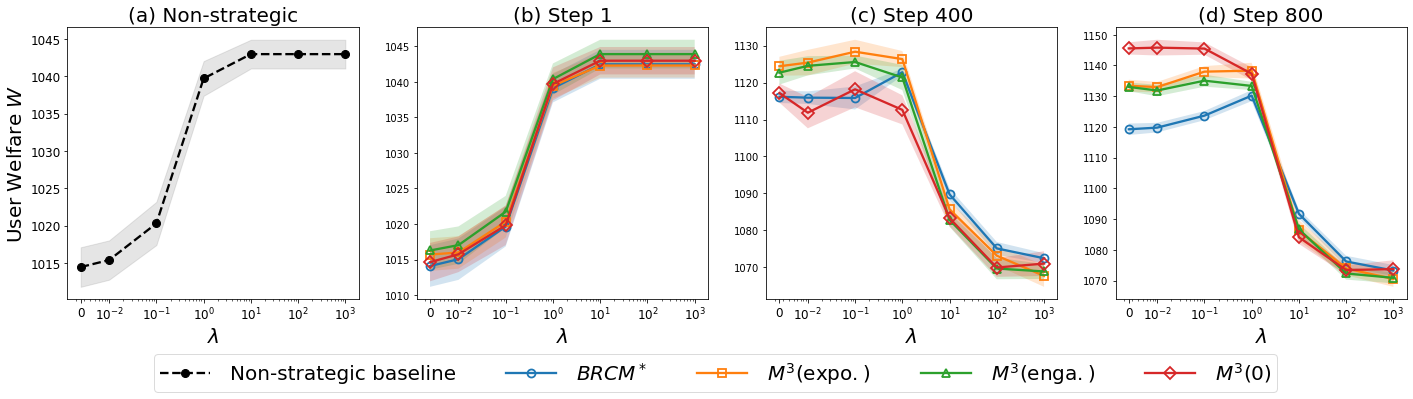

Combined chart saved to: results_B-V_tradeoffs/['BRCM_star', 'M3_expo', 'M3_enga', 'M3_0']/uni-TvN9-pure_m=400_n=10_σ=0.5_d=10_top-5_02-25-173045/uni-TvN9-pure_Top-5_Welfare-all.pdf


In [18]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import re
import string

results_folder = save_dir
subplot_labels = list(string.ascii_lowercase)

# load result data
welfare_data = {}
file_path = os.path.join(results_folder, "data", "static.pkl")
with open(file_path, "rb") as f:
    data = pickle.load(f)
    welfare_data["static"] = data['welfare_mat_static']

for mechan in mechanisms:
    file_path = os.path.join(results_folder, "data", f"{mechan}.pkl")
    with open(file_path, "rb") as f:
        data = pickle.load(f)
        welfare_data[mechan] = data['welfare_mat']

total_group = welfare_data[mechanisms[0]].shape[0]
L1_epochs = welfare_data[mechanisms[0]].shape[1]
epoch_list = np.round(np.linspace(1, L1_epochs, 3)).astype(int)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
axes = axes.flatten()

# plot the first plot (non-strategic)
ax = axes[0]
data = welfare_data["static"]  # shape: (group, trial)
avg_welfare = np.mean(data, axis=1)
std_welfare = np.std(data, axis=1)


# Replace lambda=0 (if any) to make it compatible with a log scale
lambdas_safe = lambdas.copy()
if lambdas[-1] / lambdas[1] > 50:
    zero_indices = np.where((lambdas_safe[:-1] == 0))[0]
    # Replace with lambdas[i+1] / 4
    lambdas_safe[zero_indices] = lambdas_safe[zero_indices + 1] / 4
    # x-axis settings: log scale + sparse xticks
    step = max(1, total_group // 10)
    xtick_positions = lambdas_safe[::step]
    xtick_labels = [
        "0" if lambdas[i] == 0 else rf"$10^{{{int(np.log10(lambdas[i]))}}}$"
        for i in range(len(xtick_positions))
    ]
    ax.set_xscale('log')
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, fontsize=12)
else:
    ax.set_xticks(ticks=lambdas, labels=[f"{x:.1f}" for x in lambdas], fontsize=12)


legend_handles = []
legend_labels = []
collected_labels = set()

sta_label = "Non-strategic baseline"
sta_line, = ax.plot(
    lambdas_safe,
    avg_welfare,
    color='black',
    marker='o',
    markersize=8,
    linewidth=2.3,
    linestyle='--',
    label = sta_label
)
legend_handles.append(sta_line)
legend_labels.append(sta_label)
collected_labels.add(sta_label)
ax.fill_between(
    lambdas_safe,
    avg_welfare - width * std_welfare,
    avg_welfare + width * std_welfare,
    color='gray',
    alpha=0.2
)


ax.set_xlabel(r"$\lambda$", fontsize=20)
ax.set_ylabel(r"User Welfare $W$", fontsize=20)
ax.set_title(f"({subplot_labels[0]}) Non-strategic", fontsize=20)
ax.tick_params(axis='y', labelsize=12)
# ax.text(-0.1, 1.05, f"({subplot_labels[0]})", transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')
# ax.grid(True, linestyle=":", alpha=0.6)

# plot last 3 subplots (strategic)
for j, epoch in enumerate(epoch_list):
    ax = axes[j + 1]
    for mechan in mechanisms:
        # if mechan == 'BRCM_1':
        #     continue
        data = welfare_data[mechan]
        if epoch > data.shape[1]:
            continue
        avg_welfare = np.mean(data[:, epoch - 1, :], axis=1)
        std_welfare = np.std(data[:, epoch - 1, :], axis=1)

        label_map = {
            'BRCM_star': r'$BRCM^*$',
            'M3_expo': r'$M^3\mathrm{(expo.)}$',
            'M3_enga': r'$M^3\mathrm{(enga.)}$',
            'M3_0': r'$M^3(0)$'
        }
        label = label_map.get(mechan, mechan)
        style = style_map[mechan]
        line, = ax.plot(
            lambdas_safe,
            avg_welfare,
            label=label,
            color=style["color"],
            marker=style["marker"],
            markersize=8,
            markerfacecolor='none', 
            markeredgewidth=1.8,
            linewidth=2.3
        )
        if label not in collected_labels:
            legend_handles.append(line)
            legend_labels.append(label)
            collected_labels.add(label)
        ax.fill_between(lambdas_safe,
                        avg_welfare - width * std_welfare,
                        avg_welfare + width * std_welfare,
                        alpha=0.2)
        
    ax.set_title(f"({subplot_labels[j + 1]}) Step {epoch}", fontsize=20)
    ax.set_xlabel(r"$\lambda$", fontsize=20)

    if lambdas[-1] / lambdas[1] > 50:
        zero_indices = np.where((lambdas_safe[:-1] == 0))[0]
        # Replace with lambdas[i+1] / 4
        lambdas_safe[zero_indices] = lambdas_safe[zero_indices + 1] / 4
        # x-axis settings: log scale + sparse xticks
        step = max(1, total_group // 10)
        xtick_positions = lambdas_safe[::step]
        xtick_labels = [
        "0" if lambdas[i] == 0 else rf"$10^{{{int(np.log10(lambdas[i]))}}}$"
        for i in range(len(xtick_positions))
        ]
        ax.set_xscale('log')
        ax.set_xticks(xtick_positions)
        ax.set_xticklabels(xtick_labels, fontsize=12)
    else:
        ax.set_xticks(ticks=lambdas, labels=[f"{x:.1f}" for x in lambdas], fontsize=12)


fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.16),  
    ncol=len(legend_labels),
    fontsize=20,
    frameon=True,
    fancybox=True,
    edgecolor='lightgray',
    borderpad=0.3,       
    handlelength=2.5,
    columnspacing=2.5,   
    handletextpad=1   
)



plt.show()
plt.tight_layout()
filename = re.sub(r'[<>:"/\\|?*]', '', f"{data_source}_Top-{K}_Welfare-all").replace(" ", "_") + ".pdf"
save_path = os.path.join(results_folder, filename)
fig.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.close()
print(f"Combined chart saved to: {save_path}")
